# Machine Learning for Computational Physics

## Predicting Critical Temperature of Superconductors

**Author:** Kaveri Yadav

### Project Goal

The objective of this project is to investigate whether machine learning can predict the critical temperature (Tc) of superconducting materials using their physical and chemical descriptors.

This project demonstrates data analysis, computational physics, machine learning, and scientific visualization.

### Workflow

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Train Machine Learning Models
8. Evaluate Performance
9. Scientific Interpretation
10. Conclusion

# Predict Physical Quantities Using Machine Learning

1. Introduction

2. Dataset Description

3. Exploratory Data Analysis (EDA)
   • Load Dataset
   • Dataset Information
   • Missing Values
   • Summary Statistics
   • Histogram
   • Scatter Plot
   • Observations

4. Linear Regression (Baseline Model)
   • Train-Test Split
   • Model Training
   • Predictions
   • Performance Metrics
   • Actual vs Predicted Plot
   • Discussion

5. Random Forest Regression
   • Model Training
   • Predictions
   • Performance Metrics
   • Model Comparison
   • Feature Importance
   • Feature Importance Plot
   • Feature Importance Analysis

6. Cross Validation

7. Hyperparameter Tuning

8. Model Saving

9. Conclusion

10. Future Work

### Import libraries & Load Dataset

In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [10]:
df = pd.read_csv(r"D:\Projects\Predict-Physical-Quantities-Using-Machine-Learning\data\raw\train.csv")

In [11]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [12]:
df.shape

(21263, 82)

In [13]:
df.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie      

In [15]:
df.describe()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
count,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,...,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000
mean,4.115224,87.557631,72.988310,71.290627,58.539916,1.165608,1.063884,115.601251,33.225218,44.391893,...,3.153127,3.056536,3.055885,1.295682,1.052841,2.041010,1.483007,0.839342,0.673987,34.421219
std,1.439295,29.676497,33.490406,31.030272,36.651067,0.364930,0.401423,54.626887,26.967752,20.035430,...,1.191249,1.046257,1.174815,0.393155,0.380291,1.242345,0.978176,0.484676,0.455580,34.254362
min,1.000000,6.941000,6.423452,5.320573,1.960849,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000210
25%,3.000000,72.458076,52.143839,58.041225,35.248990,0.966676,0.775363,78.512902,16.824174,32.890369,...,2.116732,2.279705,2.091251,1.060857,0.775678,1.000000,0.921454,0.451754,0.306892,5.365000
50%,4.000000,84.922750,60.696571,66.361592,39.918385,1.199541,1.146783,122.906070,26.636008,45.123500,...,2.618182,2.615321,2.434057,1.368922,1.166532,2.000000,1.063077,0.800000,0.500000,20.000000
75%,5.000000,100.404410,86.103540,78.116681,73.113234,1.444537,1.359418,154.119320,38.356908,59.322812,...,4.026201,3.727919,3.914868,1.589027,1.330801,3.000000,1.918400,1.200000,1.020436,63.000000
max,9.000000,208.980400,208.980400,208.980400,208.980400,1.983797,1.958203,207.972460,205.589910,101.019700,...,7.000000,7.000000,7.000000,2.141963,1.949739,6.000000,6.992200,3.000000,3.000000,185.000000


### Data Exploration (EDA):

### stage-1: Data Exploration(EDA):

In [16]:
print("Rows and Columns:", df.shape)

Rows and Columns: (21263, 82)


In [17]:
df.isnull().sum()

number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp            0
Length: 82, dtype: int64

In [18]:
list(df.columns)

['number_of_elements',
 'mean_atomic_mass',
 'wtd_mean_atomic_mass',
 'gmean_atomic_mass',
 'wtd_gmean_atomic_mass',
 'entropy_atomic_mass',
 'wtd_entropy_atomic_mass',
 'range_atomic_mass',
 'wtd_range_atomic_mass',
 'std_atomic_mass',
 'wtd_std_atomic_mass',
 'mean_fie',
 'wtd_mean_fie',
 'gmean_fie',
 'wtd_gmean_fie',
 'entropy_fie',
 'wtd_entropy_fie',
 'range_fie',
 'wtd_range_fie',
 'std_fie',
 'wtd_std_fie',
 'mean_atomic_radius',
 'wtd_mean_atomic_radius',
 'gmean_atomic_radius',
 'wtd_gmean_atomic_radius',
 'entropy_atomic_radius',
 'wtd_entropy_atomic_radius',
 'range_atomic_radius',
 'wtd_range_atomic_radius',
 'std_atomic_radius',
 'wtd_std_atomic_radius',
 'mean_Density',
 'wtd_mean_Density',
 'gmean_Density',
 'wtd_gmean_Density',
 'entropy_Density',
 'wtd_entropy_Density',
 'range_Density',
 'wtd_range_Density',
 'std_Density',
 'wtd_std_Density',
 'mean_ElectronAffinity',
 'wtd_mean_ElectronAffinity',
 'gmean_ElectronAffinity',
 'wtd_gmean_ElectronAffinity',
 'entropy_E

In [19]:
df["critical_temp"].head()

0    29.0
1    26.0
2    19.0
3    22.0
4    23.0
Name: critical_temp, dtype: float64

In [20]:
df["critical_temp"].describe()

count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

### stage-2: Visualization

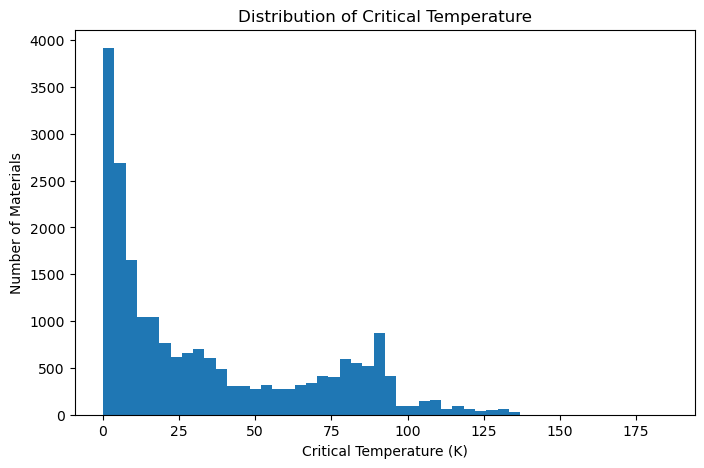

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["critical_temp"], bins=50)

plt.title("Distribution of Critical Temperature")

plt.xlabel("Critical Temperature (K)")

plt.ylabel("Number of Materials")
plt.savefig("../figures/critical_temperature_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
## This will show how superconducting materials are distributed according to their critical temperatures.

Observation: The distribution of critical temperature is positively skewed. Most superconducting materials exhibit relatively low critical temperatures (<20 K), while only a small fraction have high critical temperatures (>100 K). This imbalance should be considered during model evaluation.

### stage-3: Relationship between features and target

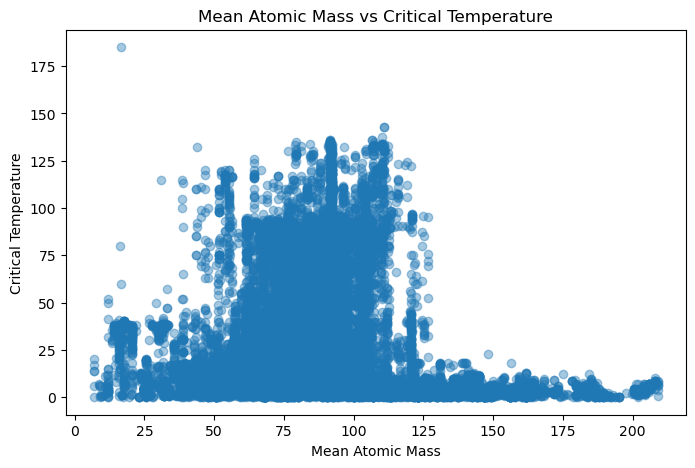

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df["mean_atomic_mass"],
            df["critical_temp"],
            alpha=0.4)

plt.xlabel("Mean Atomic Mass")

plt.ylabel("Critical Temperature")

plt.title("Mean Atomic Mass vs Critical Temperature")
plt.savefig("../figures/atomic_mass_vs_tc.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
## This is a simple scatter plot that helps us see whether heavier materials tend to have different critical temperatures.

Observation: The scatter plot indicates that mean atomic mass alone is not a strong predictor of critical temperature. The wide distribution of data points suggests a weak linear correlation, highlighting the need for machine learning models that can learn from multiple material features simultaneously.

### stage-4 ML

In [23]:
X = df.drop("critical_temp", axis=1)

y = df["critical_temp"]

In [24]:
print("Features shape :", X.shape)
print("Target shape :", y.shape)

Features shape : (21263, 81)
Target shape : (21263,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [26]:
print("Training data :", X_train.shape)
print("Testing data :", X_test.shape)

Training data : (17010, 81)
Testing data : (4253, 81)


### Stage-5: First Machine Learning Model (Linear Regression)

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model = LinearRegression()

In [29]:
model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test)

In [31]:
print("Actual values")
print(y_test.head(10))

print("\nPredicted values")
print(y_pred[:10])

Actual values
13976     6.40
1710     91.20
369      38.00
1698     19.00
13540    11.00
7405     62.00
7363     84.00
4269     50.10
3211     35.00
8957      8.02
Name: critical_temp, dtype: float64

Predicted values
[ 4.02112777 78.79022379 59.00244334 28.45591439  6.51728226 64.13549839
 61.67811696 71.73378071 31.51535521 19.20469372]


In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 13.210522050794
Mean Squared Error (MSE): 302.0075125501324
Root Mean Squared Error (RMSE): 17.378363344979654
R² Score: 0.7376312737138966


## Linear Regression Results

The Linear Regression model achieved an R² score of **0.738**, indicating that approximately **73.8%** of the variation in the critical temperature can be explained by the input material descriptors.

The Mean Absolute Error (MAE) was **13.21 K**, meaning that the model's predictions differed from the actual critical temperature by an average of about **13 Kelvin**.

The Root Mean Squared Error (RMSE) was **17.38 K**, which is higher than the MAE, indicating that the model makes some relatively large prediction errors for certain superconducting materials.

Overall, Linear Regression provides a good baseline model; however, the complex nonlinear relationships between material properties and superconducting critical temperature suggest that more advanced machine learning models may achieve better predictive performance.

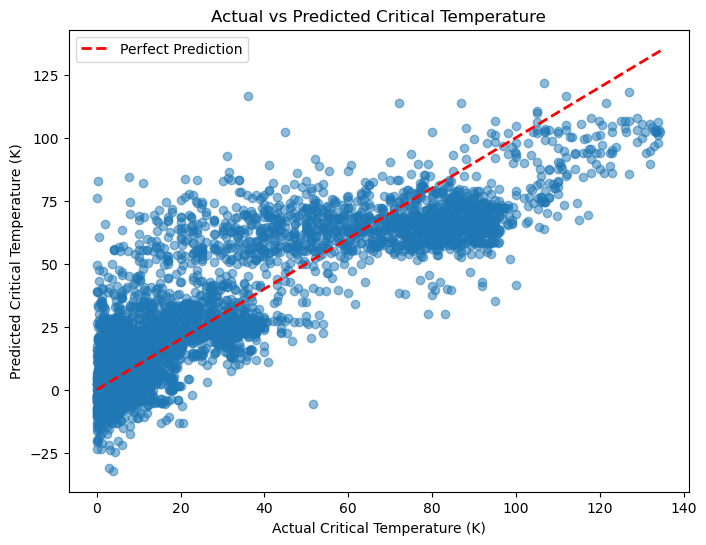

In [33]:
## actual vs predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Critical Temperature (K)")
plt.ylabel("Predicted Critical Temperature (K)")
plt.title("Actual vs Predicted Critical Temperature")
plt.legend()
plt.savefig("../figures/actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### stage-6: Random Forest Regression

In [34]:
from sklearn.ensemble import RandomForestRegressor
## model training
rf_model = RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42)

In [35]:
## Model Prediction
rf_pred = rf_model.predict(X_test)

#### Model Evaluation

The performance of the Random Forest model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R² Score)

These metrics measure the prediction accuracy of the model and allow comparison with the Linear Regression baseline.

In [36]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² :", rf_r2)

Random Forest Results
---------------------
MAE : 5.162105182617295
RMSE: 9.14232355615062
R² : 0.9273881510887722


In [37]:
## Model Comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2 Score": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,13.210522,17.378363,0.737631
1,Random Forest,5.162105,9.142324,0.927388


In [38]:
## Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
67,range_ThermalConductivity,0.535638
64,wtd_gmean_ThermalConductivity,0.126368
9,std_atomic_mass,0.026436
74,wtd_gmean_Valence,0.020827
66,wtd_entropy_ThermalConductivity,0.011472
31,mean_Density,0.011246
80,wtd_std_Valence,0.010446
43,gmean_ElectronAffinity,0.010412
72,wtd_mean_Valence,0.010054
62,wtd_mean_ThermalConductivity,0.009862


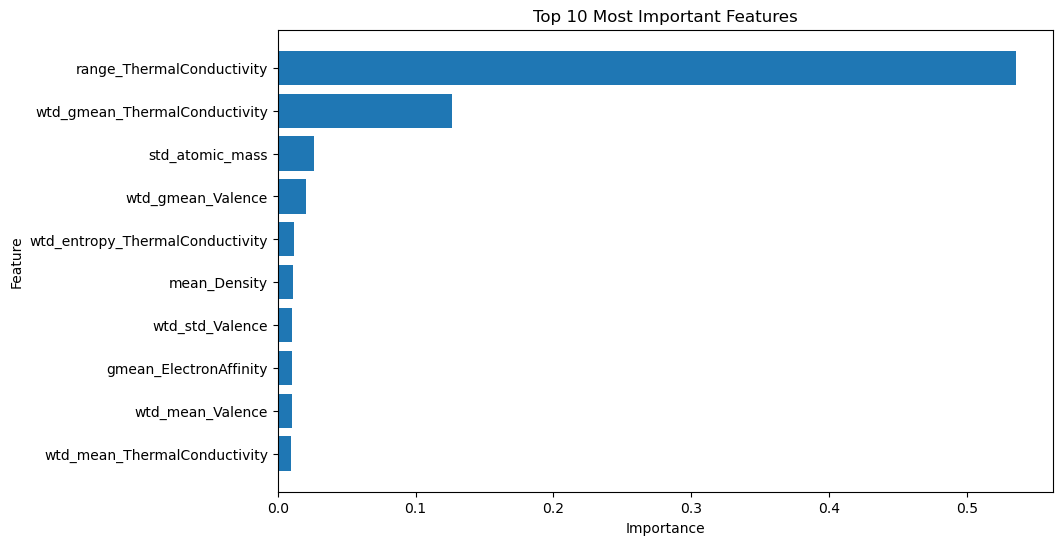

In [39]:
top10 = importance.head(10)

## Feature Importance Visualization
plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()
plt.savefig("../figures/feature_importance.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

## Feature Importance Analysis

Feature importance analysis was performed using the Random Forest Regressor to identify the material descriptors that contribute most significantly to predicting the superconducting critical temperature (Tc).

The analysis revealed that a small subset of features has a much greater influence on the model's predictions than the remaining variables. This indicates that superconducting behavior is governed by the combined effects of multiple physical and chemical properties rather than by a single material descriptor.

The feature importance results also demonstrate one of the major advantages of tree-based machine learning models: besides providing accurate predictions, they help identify the most influential variables in complex materials datasets. Such insights can assist researchers in understanding which material characteristics should be prioritized when designing or discovering new superconducting materials.

### stage-7: cross validation

In [40]:
from sklearn.model_selection import cross_val_score

In [41]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [42]:
print("Cross Validation R² Scores")

print(cv_scores)

Cross Validation R² Scores
[0.70904732 0.68991189 0.87289947 0.78389388 0.63873398]


In [43]:
print("Average R² Score :", cv_scores.mean())

Average R² Score : 0.7388973089022844


In [44]:
print("Standard Deviation :", cv_scores.std())

Standard Deviation : 0.08161440692069417


### Cross Validation Discussion

To evaluate the robustness and generalization ability of the Random Forest model, 5-fold cross-validation was performed using the R² score as the evaluation metric.

The average cross-validation R² score obtained was **0.739**, which is very close to the R² score achieved on the independent test set. This indicates that the model performs consistently on different subsets of the dataset and is not overly dependent on a particular train-test split.

The standard deviation of **0.082** suggests moderate variability across the folds, indicating reasonable model stability while also highlighting opportunities for further improvement through hyperparameter tuning.

### Hyperparameter Tuning

In [45]:
RandomForestRegressor(
    n_estimators=30
)

RandomForestRegressor(n_estimators=30)

In [46]:
## Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [30, 50],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [47]:
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=4,   # only 4 combinations
    cv=3,     # only 2-fold CV
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

In [48]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [30, 50]},
                   random_state=42, scoring='r2')

In [49]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 30, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}


In [50]:
print("Best Cross Validation Score:")
print(random_search.best_score_)

Best Cross Validation Score:
0.9101045572341033


In [51]:
best_rf = random_search.best_estimator_

best_pred = best_rf.predict(X_test)

best_mae = mean_absolute_error(y_test, best_pred)
best_mse = mean_squared_error(y_test, best_pred)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_pred)

print("===== Tuned Random Forest =====")
print(f"MAE  : {best_mae:.3f}")
print(f"RMSE : {best_rmse:.3f}")
print(f"R²   : {best_r2:.3f}")

===== Tuned Random Forest =====
MAE  : 5.173
RMSE : 9.047
R²   : 0.929


In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae,
        best_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        best_rmse
    ],
    "R² Score": [
        r2,
        rf_r2,
        best_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,13.210522,17.378363,0.737631
1,Random Forest,5.162105,9.142324,0.927388
2,Tuned Random Forest,5.173197,9.046832,0.928897


### Hyperparameter Tuning Discussion

Hyperparameter tuning was performed using RandomizedSearchCV to optimize the Random Forest model. Different combinations of model parameters were evaluated using cross-validation to identify the configuration that achieved the best predictive performance.

The tuned Random Forest model achieved an R² score of approximately 0.929, representing a slight improvement over the baseline Random Forest model (R² = 0.927). Although the improvement was modest, the optimization process confirmed that the selected hyperparameters enhanced the model's predictive accuracy while maintaining good generalization performance.

These results demonstrate the importance of systematic hyperparameter optimization in developing robust machine learning models for materials science applications.

In [53]:
import os
print(os.getcwd())

d:\Projects\Predict-Physical-Quantities-Using-Machine-Learning\notebooks


In [54]:
import os

print(os.path.exists("../models"))

True


In [55]:
import joblib

joblib.dump(best_rf, "../models/random_forest_superconductor.pkl")

['../models/random_forest_superconductor.pkl']

### 8. Residual Analysis

In [56]:
residuals = y_test - best_pred

residuals.head()

13976   -4.889503
1710     6.717603
369      9.523648
1698     1.506684
13540    0.380875
Name: critical_temp, dtype: float64

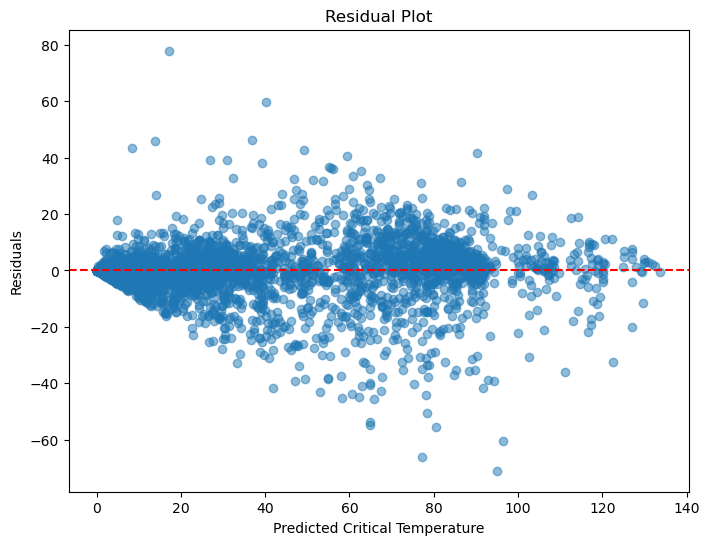

In [57]:
## Scatter Plot of Residuals
plt.figure(figsize=(8,6))

plt.scatter(best_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Critical Temperature")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("../figures/residual_plot.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

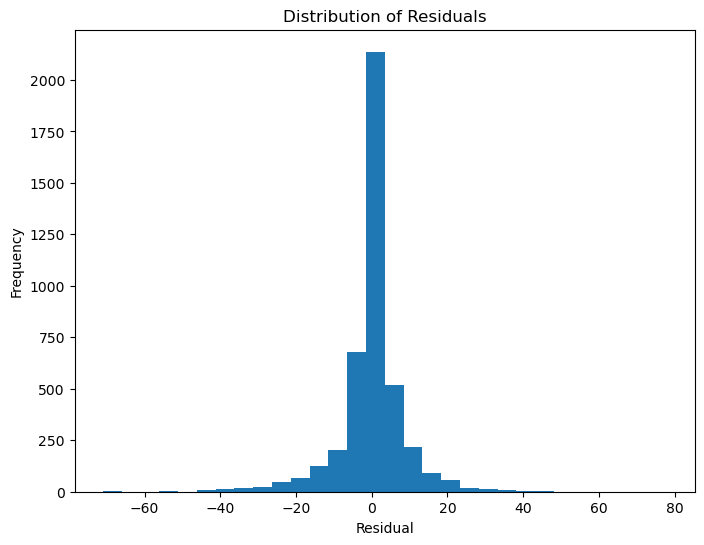

In [58]:
## Histogram of Residuals
plt.figure(figsize=(8,6))

plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.savefig("../figures/residual_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [59]:
## Residual Statistics
print("Mean Residual :", residuals.mean())
print("Standard Deviation :", residuals.std())
print("Minimum Residual :", residuals.min())
print("Maximum Residual :", residuals.max())

Mean Residual : -0.12662804543477418
Standard Deviation : 9.047009226641801
Minimum Residual : -71.00830820105821
Maximum Residual : 77.90688794208955


#### Residual Analysis Discussion

Residual analysis was performed to assess the prediction errors of the tuned Random Forest model.

The mean residual was approximately **−0.13**, which is very close to zero, indicating that the model does not exhibit a significant systematic bias toward overestimation or underestimation.

The residual standard deviation was approximately **9.05 K**, consistent with the model's RMSE, indicating stable prediction errors across the test dataset.

Although a small number of samples exhibited relatively large residuals, these are likely associated with materials possessing complex or uncommon physical characteristics that are more difficult to model accurately.

Overall, the residual analysis supports the conclusion that the tuned Random Forest model provides reliable predictions for superconducting critical temperature while maintaining good generalization performance.

### XGBoost Regression

In [60]:
import sys
print(sys.executable)

c:\Users\mona2\anaconda3\python.exe


In [61]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [62]:
from xgboost import XGBRegressor
print("XGBoost installed successfully!")

XGBoost installed successfully!


In [63]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [64]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [66]:
y_pred_xgb = xgb_model.predict(X_test)

In [70]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 5.8431
RMSE: 9.3378
R²  : 0.9242


In [82]:
## Linear Regression
import joblib

joblib.dump(
    model,
    "../models/linear_regression_superconductor.pkl"
)

print("✅ Linear Regression model saved.")

✅ Linear Regression model saved.


In [73]:
## Linear Regression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred_lr = model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"MAE : {lr_mae:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"R²  : {lr_r2:.4f}")

Linear Regression
MAE : 13.2105
RMSE: 17.3784
R²  : 0.7376


In [74]:
## RandomForest
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"MAE : {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest
MAE : 5.1621
RMSE: 9.1423
R²  : 0.9274


In [83]:
## Tuned Random Forest
best_rf = random_search.best_estimator_

joblib.dump(
    best_rf,
    "../models/tuned_random_forest_superconductor.pkl"
)

print("✅ Tuned Random Forest model saved.")

✅ Tuned Random Forest model saved.


In [75]:
## Tuned Random Forest
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = root_mean_squared_error(y_test, y_pred_tuned)
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print(f"MAE : {tuned_mae:.4f}")
print(f"RMSE: {tuned_rmse:.4f}")
print(f"R²  : {tuned_r2:.4f}")

Tuned Random Forest
MAE : 5.1732
RMSE: 9.0468
R²  : 0.9289


In [84]:
## XGBoost model
joblib.dump(
    xgb_model,
    "../models/xgboost_superconductor.pkl"
)

print("✅ XGBoost model saved.")

✅ XGBoost model saved.


### Model Performance Comparison

To evaluate the effectiveness of different machine learning algorithms for predicting the superconducting critical temperature (Tc), four regression models were trained and tested on the same dataset.

The models were evaluated using three standard regression metrics:

- **MAE (Mean Absolute Error):** Measures the average prediction error.
- **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors more heavily.
- **R² Score (Coefficient of Determination):** Indicates how well the model explains the variance in the target variable. Higher values indicate better predictive performance.

The table below summarizes the performance of all trained models.

In [77]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost"
    ],
    "MAE": [
        13.2105,
        5.1621,
        5.1732,
        5.8431
    ],
    "RMSE": [
        17.3784,
        9.1423,
        9.0468,
        9.3378
    ],
    "R² Score": [
        0.7376,
        0.9274,
        0.9289,
        0.9242
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,13.2105,17.3784,0.7376
1,Random Forest,5.1621,9.1423,0.9274
2,Tuned Random Forest,5.1732,9.0468,0.9289
3,XGBoost,5.8431,9.3378,0.9242


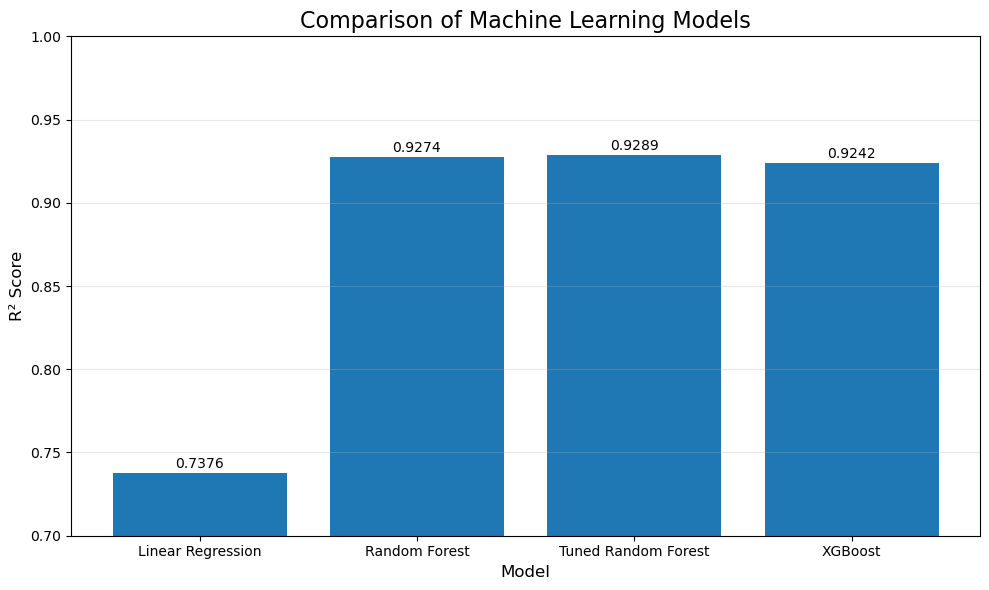

In [85]:
## Comparison Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(results["Model"], results["R² Score"])

plt.title("Comparison of Machine Learning Models", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0.70,1.00)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.003,
        f"{y:.4f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
import os

os.makedirs("../results", exist_ok=True)

results.to_csv(
    "../results/model_performance.csv",
    index=False
)

print("✅ Results saved.")

✅ Results saved.


### SHAP Explainability

Machine learning models such as Random Forest and XGBoost often provide high predictive accuracy but are considered "black-box" models because their decision-making process is difficult to interpret.

To improve interpretability, SHAP (SHapley Additive exPlanations) is used. SHAP assigns an importance value to each feature for every prediction, allowing us to understand how individual material properties influence the predicted superconducting critical temperature (Tc).

This analysis helps identify the most influential features and provides insights into the relationship between material characteristics and superconductivity.

In [87]:
%pip install shap

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -------- ------------------------------- 2.6/12.6 MB 15.1 MB/s eta 0:00:01
   ------------ --------------------------- 3.9/12.6 MB 9.4 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.6 MB 8.6 MB/s eta 0:00:01
   -------------------- ------------------- 6.6/12.6 MB 7.9 MB/s eta 0:00:01
   ------------------------- -------------- 8.1/12.6 MB 7.6 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.6 MB 7.4 MB/s eta 0:00:01
   --------------------------------- ------ 10.5/12.6 MB 7.0 MB/s eta 0:00:01
   -------------------------------------- - 12.1/12.6 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 6.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.


In [88]:
import shap

In [90]:
## Creating the Explainer
explainer = shap.TreeExplainer(best_rf)

In [91]:
## Calculating SHAP Values
shap_values = explainer.shap_values(X_test)

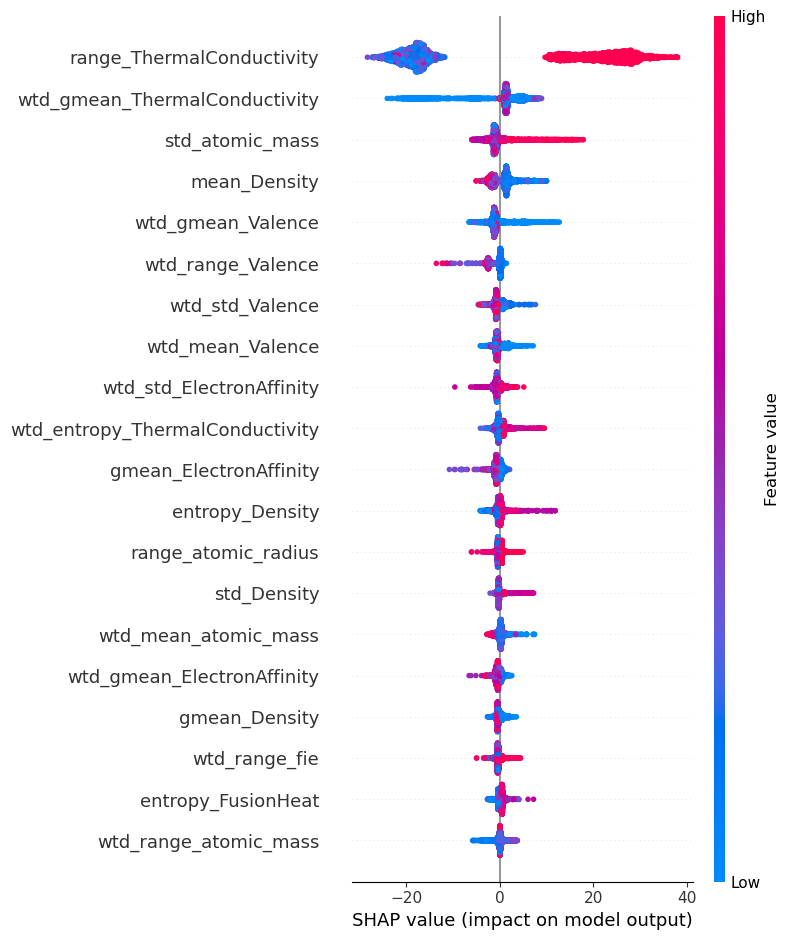

In [92]:
## summary plot:SHAP figure
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show() 

##This plot answers-
##Which features matter most?
## Whether high or low values of each feature increase or decrease the predicted Tc.

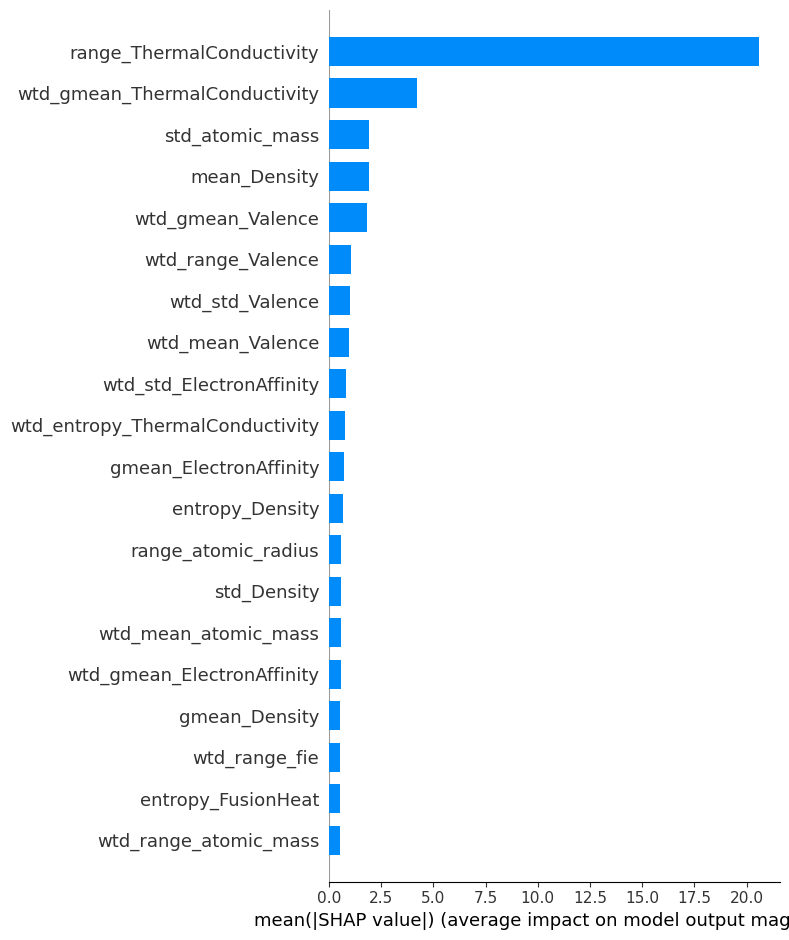

In [93]:
## bar plot
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../figures/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()  ## gives a global ranking of feautre importance.

### Interpretation of SHAP Results

SHAP (SHapley Additive exPlanations) was used to interpret the predictions of the tuned Random Forest model.

## Summary Plot

The SHAP summary plot ranks the features according to their overall contribution to the model's predictions.

- Features at the top of the plot have the greatest influence on predicting the superconducting critical temperature (Tc).
- Each point represents one material sample.
- Red points indicate high feature values, while blue points indicate low feature values.
- The horizontal position shows whether a feature increases or decreases the predicted Tc.

## SHAP Feature Importance Plot

The SHAP bar plot presents the average absolute SHAP value for each feature.

Features with larger SHAP values contribute more strongly to the prediction of the superconducting critical temperature.

This analysis improves the interpretability of the machine learning model by identifying which material properties are most influential in predicting superconducting behavior.